# HR Analytics: Employee Attrition Prediction using Logistic Regression

SUBMITTED BY:
Parmeet kaur
B.TECH(Information Technology)
Guru Tegh Bahadur Institue of Technology(GTBIT)
GGSIPU
Academic Year:2024-2028

Project Overview

Employee attrition is a major challenge for organizations as it impacts productivity, increases recruitment costs, and affects overall business performance. This project aims to predict whether an employee is likely to leave the organization based on various employee-related factors.

The dataset is analyzed using Exploratory Data Analysis (EDA), followed by data preprocessing, feature selection, model building, and evaluation. A Logistic Regression model is used for prediction, while SHAP (SHapley Additive exPlanations) is applied to interpret the model and identify the most influential features affecting employee attrition.

# IMPORT LIBRARIES

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# SHAP Explainability
import shap

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# LOAD DATASET

The dataset is loaded into a Pandas DataFrame to understand its structure and prepare it for analysis. The first few records are displayed to verify that the data has been imported successfully.

In [3]:
# Load Dataset
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Display first five rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Dataset Information

This section provides an overview of the dataset, including the number of rows and columns, data types, missing values, and descriptive statistics. Understanding the dataset is essential before performing preprocessing and model development.

In [4]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.shape)
print(df.describe())
print(df.columns)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify patterns, analyze feature distributions, and examine relationships between variables. Visualization techniques help uncover meaningful insights before building the machine learning model.

# Distribution of Employee Attrition

This visualization shows the number of employees who stayed in the organization and those who left. It helps understand the class distribution of the target variable.

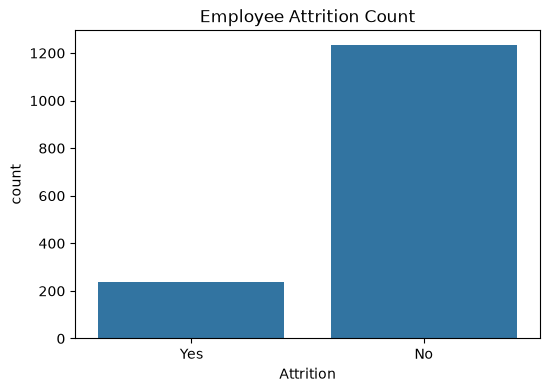

In [11]:
#1.Attrition Count

plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Count")
plt.show()

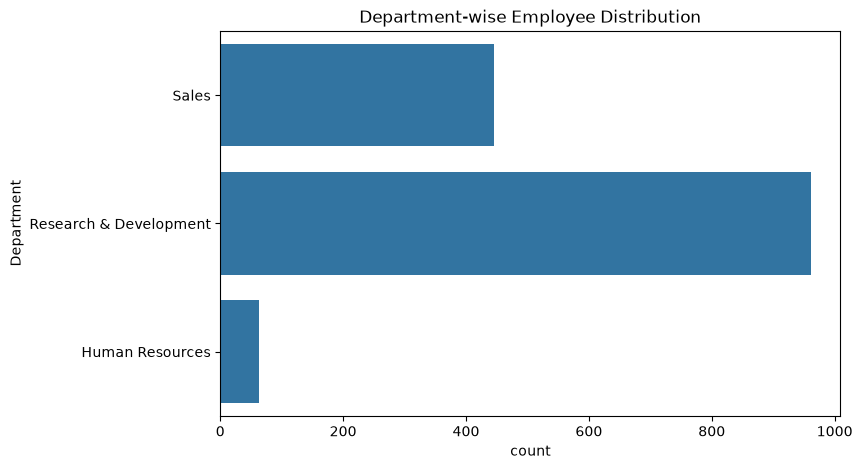

In [7]:
#2.Attrition by Department
plt.figure(figsize=(8,5))
sns.countplot(y='Department', data=df)
plt.title("Department-wise Employee Distribution")
plt.show()

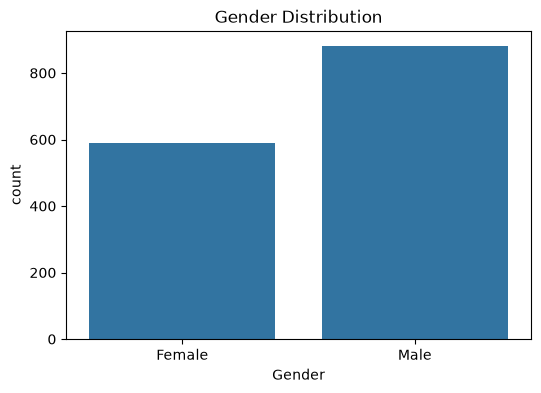

In [6]:
#3.Attrition by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

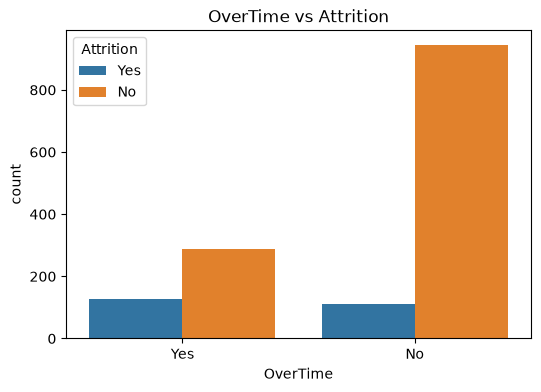

In [12]:
#4.ATTRITION BY OVERTIME
plt.figure(figsize=(6,4))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OverTime vs Attrition")
plt.show()

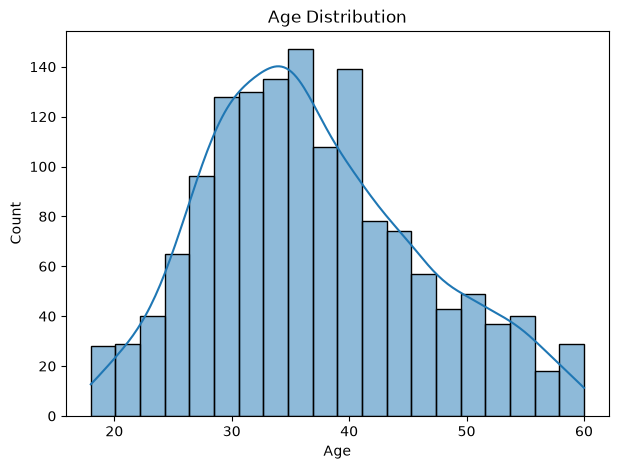

In [9]:
#5.Age Distribution
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

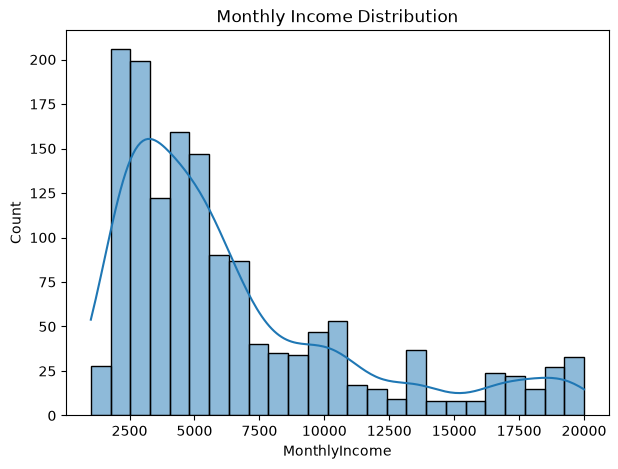

In [10]:
#6.Monthly Income Distribution
plt.figure(figsize=(7,5))
sns.histplot(df['MonthlyIncome'], bins=25, kde=True)
plt.title("Monthly Income Distribution")
plt.show()

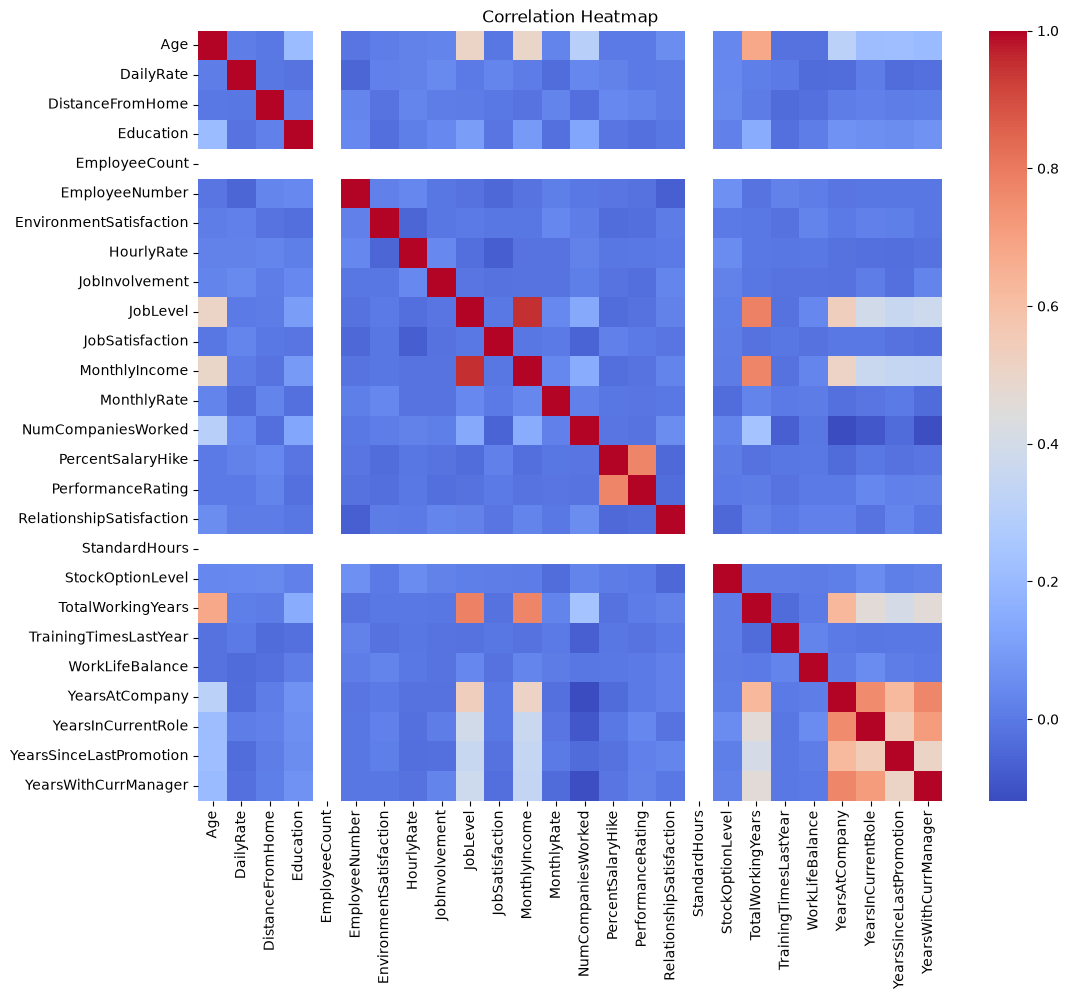

In [13]:
#7.Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),annot=False ,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing

Data preprocessing is an essential step in machine learning that prepares the dataset for model training. In this phase, unnecessary columns are removed, categorical variables are converted into numerical values using Label Encoding, and the data is transformed into a format suitable for the Logistic Regression model.

In [14]:
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [15]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [16]:
#Check missing values after preprocessing
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# Feature and Target Selection

Feature selection involves separating the independent variables (features) from the target variable. In this project, the Attrition column is selected as the target variable, while all remaining columns are used as input features for model training.

In [17]:
#Separate features and target variable
X = df.drop('Attrition', axis=1)

y = df['Attrition']

# Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the Logistic Regression model, while the testing data is used to evaluate the model's performance on unseen data.

In [18]:
#Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

Feature scaling is performed to standardize the numerical features so that they have a mean of 0 and a standard deviation of 1. This helps improve the performance and stability of machine learning algorithms such as Logistic Regression by ensuring that all features contribute equally during model training.

The training data is standardized using the "fit_transform()" method, while the testing data is scaled using the "transform()" method to prevent data leakage. Finally, the scaled NumPy arrays are converted back into Pandas DataFrames to preserve the original feature names and improve readability.

In [20]:
#FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Convert scaled arrays back to DataFrame
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)



# Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. In this project, the model is trained to predict whether an employee is likely to leave the organization based on the available features.

In [23]:
#Train LOGISTIC REGRESSION MODEL
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model Accuracy and Evaluation

The performance of the Logistic Regression model is evaluated using Accuracy Score, Confusion Matrix, and Classification Report. These metrics help assess the model's predictive capability and overall classification performance.

In [24]:
#Accuracy Store
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.891156462585034


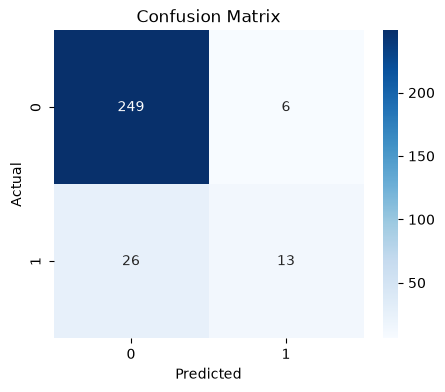

In [25]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")

plt.show()
plt.ylabel("Actual")

# SHAP Analysis

SHAP (SHapley Additive exPlanations) is an explainable AI technique used to interpret machine learning models. It measures the contribution of each feature to the model's predictions, helping identify the most influential factors affecting employee attrition. This improves the transparency and interpretability of the Logistic Regression model.

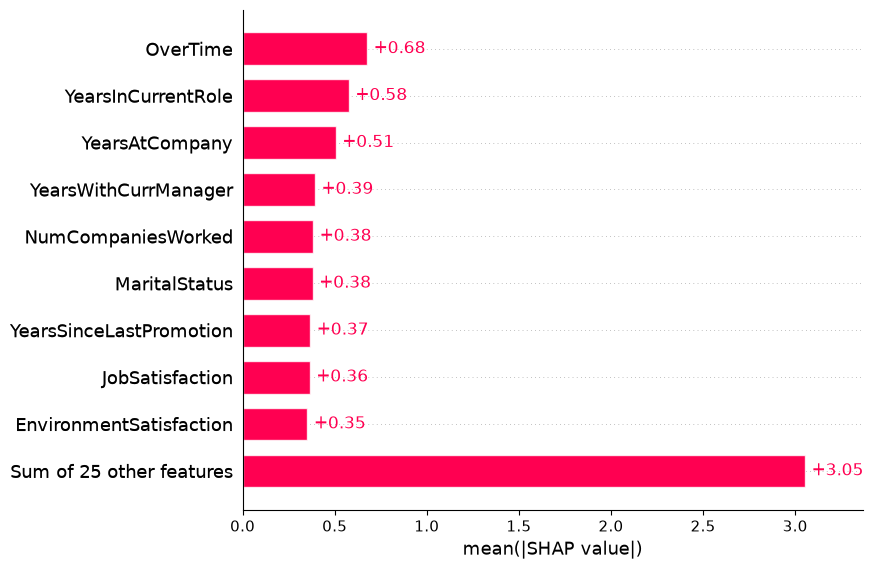

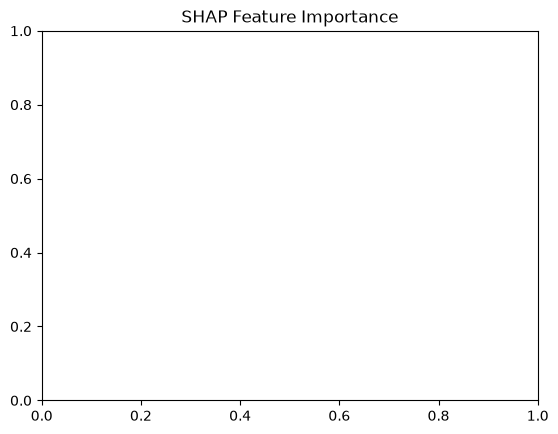

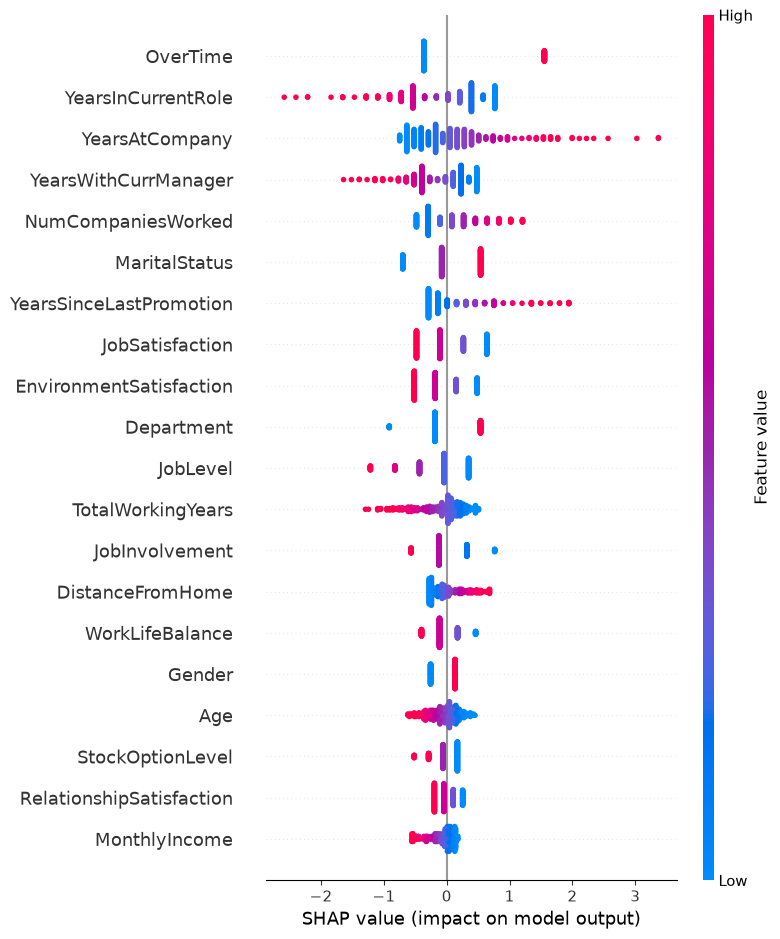

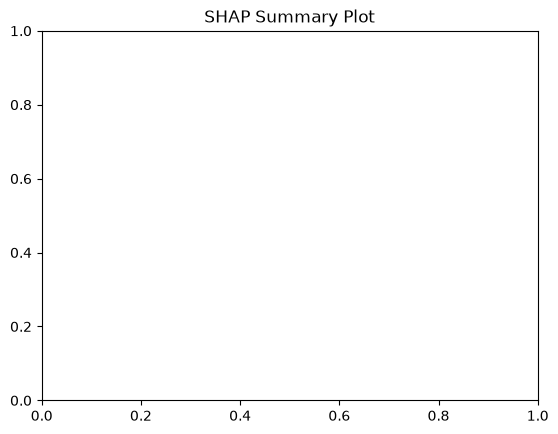

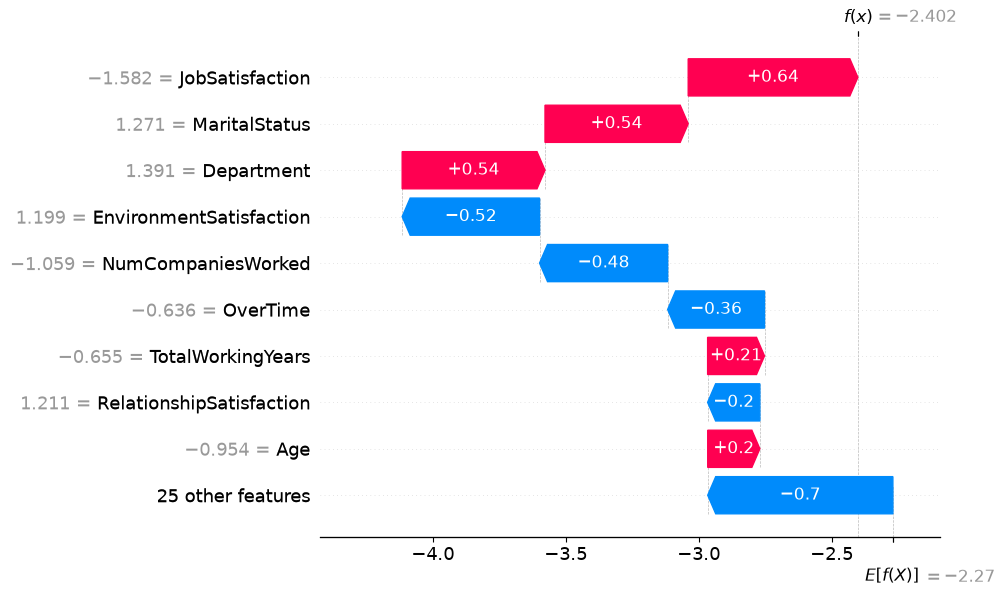

In [27]:
# SHAP ANALYSIS
import shap
import matplotlib.pyplot as plt

# Create SHAP Explainer
explainer = shap.Explainer(model, X_train)

# Calculate SHAP values
shap_values = explainer(X_test)

# SHAP Feature Importance
plt.figure(figsize=(10,6))
shap.plots.bar(shap_values)
plt.title("SHAP Feature Importance")
plt.show()

# SHAP Summary Plot
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test)
plt.title("SHAP Summary Plot")
plt.show()

# Individual Prediction Explanation
shap.plots.waterfall(shap_values[0])
plt.show()

In [26]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.68      0.33      0.45        39

    accuracy                           0.89       294
   macro avg       0.79      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294



# Conclusion

This project successfully developed an Employee Attrition Prediction model using Logistic Regression. The dataset was explored, preprocessed, and transformed before training the model. The model achieved satisfactory performance based on standard evaluation metrics such as Accuracy Score, Confusion Matrix, and Classification Report.

Furthermore, SHAP analysis provided valuable insights into the factors influencing employee attrition, improving the interpretability of the model. Overall, this project demonstrates how machine learning and explainable AI can support organizations in identifying employees who may be at risk of leaving, enabling proactive decision-making and effective workforce management.

# Key Insights

- Logistic Regression successfully classified employee attrition based on the available features.
- Data preprocessing and feature scaling improved the consistency and reliability of the model.
- The evaluation metrics indicated that the model achieved good predictive performance on the test dataset.
- SHAP analysis identified the most influential features contributing to employee attrition, making the model more transparent and      interpretable.
- Explainable AI techniques such as SHAP enhance confidence in machine learning predictions by showing how individual features influence the final outcome.